In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#baca dataset
df = pd.read_csv("../../dataset/MLP/data.csv", sep=';')

print(df.shape)
df.head()

(4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
#cek distribusi
print(df["Target"].value_counts())

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [4]:
#hapus enrolled
df = df[df["Target"] != "Enrolled"].copy()

print(df["Target"].value_counts())



Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64


In [5]:
#encode
df["Target"] = df["Target"].map({
    "Graduate": 0,
    "Dropout": 1
})

df["Target"].value_counts()

Target
0    2209
1    1421
Name: count, dtype: int64

In [6]:
#upsampling
graduate = df[df["Target"] == 0]
dropout = df[df["Target"] == 1]

dropout_upsampled = resample(
    dropout,
    replace=True,
    n_samples=len(graduate),
    random_state=42
)

df_balanced = pd.concat([graduate, dropout_upsampled])

print(df_balanced["Target"].value_counts())

Target
0    2209
1    2209
Name: count, dtype: int64


In [7]:
selected_features = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
]

print(f"Jumlah fitur: {len(selected_features)}")

Jumlah fitur: 2


In [8]:
#pisah fitur dan target
X = df_balanced[selected_features]
y = df_balanced["Target"]

print(X.shape)
print(y.shape)

(4418, 2)
(4418,)


In [9]:
#mixmax scaling
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(4418, 2)


In [17]:
#splot data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (3534, 2)
Test : (884, 2)


In [24]:
#model MLP
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
#early stop
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

#training model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6979 - loss: 0.6265 - val_accuracy: 0.7341 - val_loss: 0.5832
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7453 - loss: 0.5312 - val_accuracy: 0.7341 - val_loss: 0.5044
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7513 - loss: 0.4937 - val_accuracy: 0.7397 - val_loss: 0.4745
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7626 - loss: 0.4868 - val_accuracy: 0.7581 - val_loss: 0.4645
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7641 - loss: 0.4835 - val_accuracy: 0.7397 - val_loss: 0.4748
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7761 - loss: 0.4808 - val_accuracy: 0.7482 - val_loss: 0.4631
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7680 - loss: 0.4794 - val_accuracy: 0.7907 - val_loss: 0.4552
Epoch 8/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7740 - loss: 0.4781 - val_accuracy: 0.7426 - v

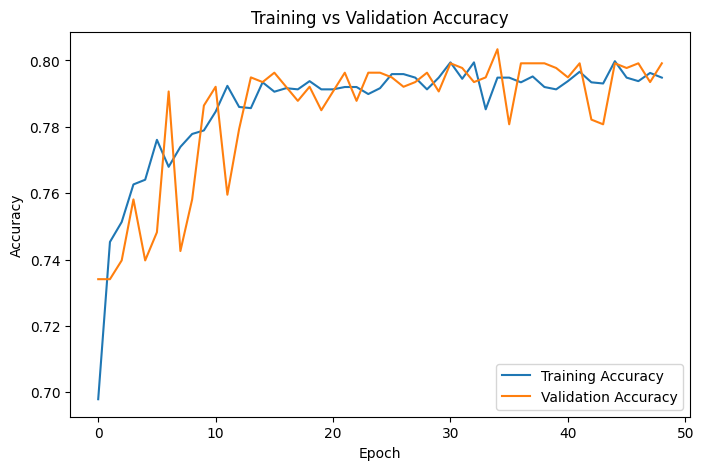

In [26]:
#grafik training
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [27]:
#prediksi
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Accuracy : 0.7885
Precision: 0.8058
Recall   : 0.7602
F1 Score : 0.7823
              precision    recall  f1-score   support

     Dropout       0.77      0.82      0.79       442
    Graduate       0.81      0.76      0.78       442

    accuracy                           0.79       884
   macro avg       0.79      0.79      0.79       884
weighted avg       0.79      0.79      0.79       884



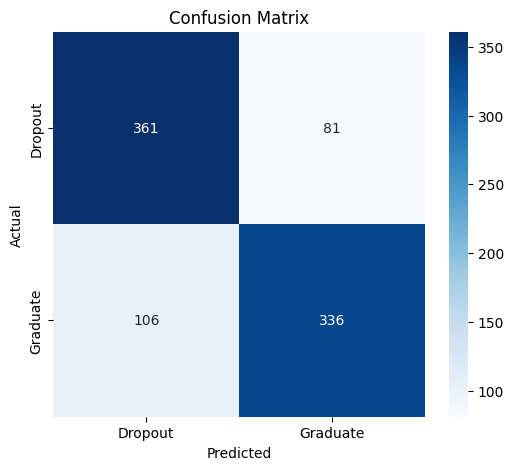

In [28]:
#evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

#classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Dropout", "Graduate"]
    )
)

#confussion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Dropout', 'Graduate'],
    yticklabels=['Dropout', 'Graduate']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [31]:
# ROC AUC
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)

roc_auc = auc(
    fpr,
    tpr
)

print(f"AUC Score : {roc_auc:.4f}")

AUC Score : 0.8470


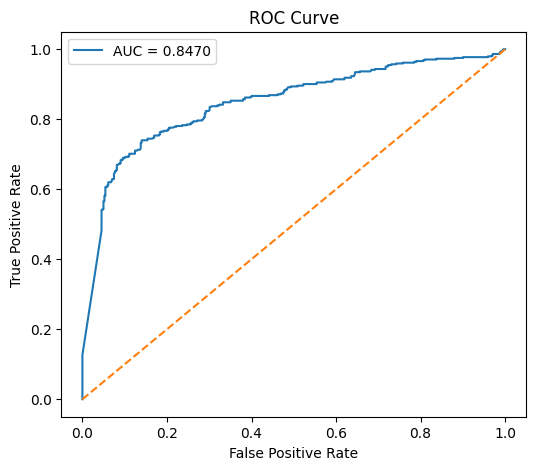

In [32]:
#plot ROC curve
plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

In [29]:
#save model
model.save("mlp_kelulusan_mahasiswa.keras")